## Rank Distance Comparison: $\mathbb{R}^n$ vs $\mathbb{R}^2$ Projection
==============================================

Computes pairwise distances in the original high-dimensional space (Rn)
and in a 2D projection (R2), ranks all pairs by distance, and visualizes
how much the rank of each pair changed.

"If two points are close in Rn, are they still among the closest pairs in the 2D projection?"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import combinations
from scipy.stats import spearmanr
from distortion_cues import ProjectionAnalysisVisualizer,utility, visualizer
# from config import GLOBAL_SEED
import config as cfg

In [2]:
# ─────────────────────────────────────────────
# 1. LOAD / GENERATE DATA
# ─────────────────────────────────────────────
 
def generate_example_data(n_points: int = 50, n_dims: int = 10, seed: int = 42):
    """Generate synthetic high-dim data and a PCA projection to R2"""
    from sklearn.decomposition import PCA
 
    rng = np.random.default_rng(seed)
    # Data lives on a low-rank manifold + noise so the projection is meaningful
    latent = rng.standard_normal((n_points, 2))
    mixing = rng.standard_normal((2, n_dims))
    noise  = rng.standard_normal((n_points, n_dims)) * 0.3
    X_Rn   = latent @ mixing + noise          # shape (n_points, n_dims)
 
    pca    = PCA(n_components=2)
    X_R2   = pca.fit_transform(X_Rn)          # shape (n_points, 2)
 
    return(X_Rn, X_R2)
 

In [3]:
 
# ─────────────────────────────────────────────
# 2. PAIRWISE DISTANCES & RANKING
# ─────────────────────────────────────────────
 
def pairwise_distances(X: np.ndarray) -> tuple[list[tuple[int,int]], np.ndarray]:
    """Return all (i,j) pairs with i<j and their L2 distances."""
    pairs = list(combinations(range(len(X)), 2))
    dists = np.array([np.linalg.norm(X[i] - X[j]) for i, j in pairs])
    return(pairs, dists)
 
 
def rank_pairs(dists: np.ndarray) -> np.ndarray:
    """Rank pairs from smallest distance (rank 1) to largest."""
    order = np.argsort(dists)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(dists) + 1)
    return(ranks)
 

In [4]:
# ─────────────────────────────────────────────
# 3. RANK SHIFT ANALYSIS
# ─────────────────────────────────────────────
 
def rank_shift_analysis(X_Rn, X_R2):
    pairs, dist_Rn = pairwise_distances(X_Rn)
    _,     dist_R2 = pairwise_distances(X_R2)
 
    rank_Rn = rank_pairs(dist_Rn)
    rank_R2 = rank_pairs(dist_R2)
 
    shift       = rank_R2 - rank_Rn          # signed rank change
    abs_shift   = np.abs(shift)
    n_pairs     = len(pairs)
 
    rho, p_val  = spearmanr(rank_Rn, rank_R2)
 
    return dict(
        pairs     = pairs,
        dist_Rn   = dist_Rn,
        dist_R2   = dist_R2,
        rank_Rn   = rank_Rn,
        rank_R2   = rank_R2,
        shift     = shift,
        abs_shift = abs_shift,
        n_pairs   = n_pairs,
        rho       = rho,
        p_val     = p_val,
    )

In [5]:
# ─────────────────────────────────────────────
# 4. SUMMARY TABLE
# ─────────────────────────────────────────────
 
def print_summary(res, top_k: int = 10):
    print("\n" + "=" * 60)
    print("  RANK-DISTANCE PRESERVATION SUMMARY")
    print("=" * 60)
    print(f"  Total pairs          : {res['n_pairs']:,}")
    print(f"  Spearman ρ (Rn, R2)  : {res['rho']:.4f}  (p = {res['p_val']:.2e})")
    print(f"  Mean |rank shift|    : {res['abs_shift'].mean():.2f}")
    print(f"  Median |rank shift|  : {np.median(res['abs_shift']):.2f}")
    print(f"  Max |rank shift|     : {res['abs_shift'].max()}")
    print(f"  Pairs with shift = 0 : {(res['shift'] == 0).sum():,}")
    print()
    print(f"  Top-{top_k} most disrupted pairs:")
    print(f"  {'Pair':>12}  {'Rank(Rn)':>9}  {'Rank(R2)':>9}  {'Shift':>8}")
    print("  " + "-" * 44)
    worst = np.argsort(res['abs_shift'])[::-1][:top_k]
    for k in worst:
        i, j = res['pairs'][k]
        print(f"  ({i:>3}, {j:>3})    {res['rank_Rn'][k]:>9}  "
              f"{res['rank_R2'][k]:>9}  {res['shift'][k]:>+8}")
    print("=" * 60 + "\n")
 
 

In [6]:
# dataset = 'cube_diff_size_diff_dist' # "cube_diff_size_diff_dist", "cube_diff_size_same_dist","cube_same_size_diff_dist", "tetrahedron_eq_1_close", "tetrahedron_eq_2_close" 

dataset = 'cube_diff_size_diff_dist'
method = 'tsne'  # tsne or umap

In [7]:
cfg_dt = cfg.get_config(dataset, method)
perplexity = cfg_dt["perplexity"]

In [8]:
output_folder = f"results//{dataset}/{method}_perp_{perplexity}_plots"
output_plot_folder = f"results/{dataset}/{method}_perp_{perplexity}_plots/figures"

In [9]:
D = utility.load_numpy_array(output_folder, "D", dataset)

class_label = utility.load_numpy_array(output_folder, "class_label", dataset)
low_dm_emb_orig = utility.load_numpy_array(output_folder, "low_dm_emb", dataset)
edges_delaunay_orig = np.load(f"{output_folder}/edges_delaunay_orig_{dataset}.npy")

Computing pairwise distances and ranks …

  RANK-DISTANCE PRESERVATION SUMMARY
  Total pairs          : 719,400
  Spearman ρ (Rn, R2)  : 0.4098  (p = 0.00e+00)
  Mean |rank shift|    : 169285.54
  Median |rank shift|  : 112778.50
  Max |rank shift|     : 566806
  Pairs with shift = 0 : 1

  Top-30 most disrupted pairs:
          Pair   Rank(Rn)   Rank(R2)     Shift
  --------------------------------------------
  (  6, 385)       707293     140487   -566806
  (  6, 333)       707477     141796   -565681
  (187, 385)       705149     141292   -563857
  (  6, 452)       708719     145575   -563144
  (  6, 315)       706509     143442   -563067
  (187, 333)       705423     142538   -562885
  (187, 452)       706884     146358   -560526
  (  6, 545)       705135     145097   -560038
  (187, 315)       704281     144377   -559904
  (  6, 394)       703120     144885   -558235
  (190, 385)       699938     143052   -556886
  (187, 545)       702846     146048   -556798
  (  6, 589)       70

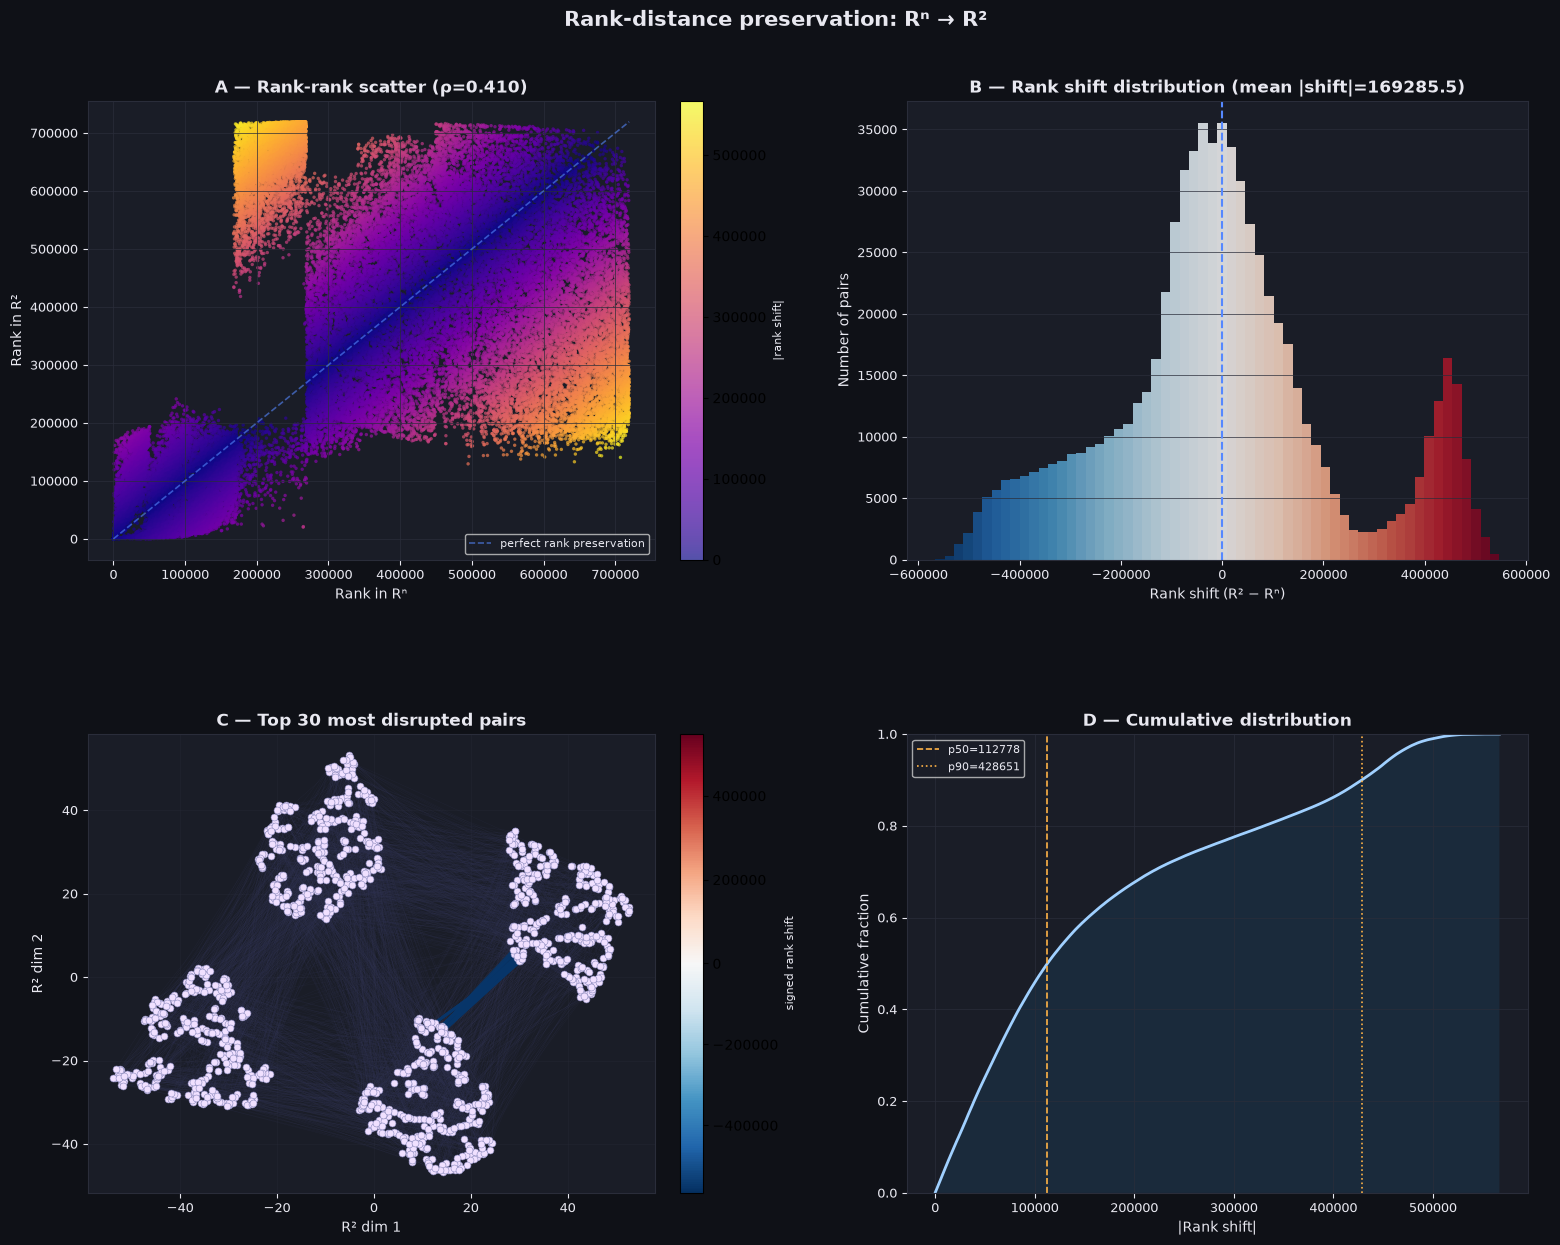

In [10]:

# ─────────────────────────────────────────────
# 6. MAIN
# ─────────────────────────────────────────────
 
if __name__ == "__main__":
    # ── Replace this block with your own data loading ──────────────────
    #
    #   import pandas as pd
    #   X_Rn = pd.read_csv("your_high_dim_data.csv").values   # (N, n_dims)
    #   X_R2 = pd.read_csv("your_2d_projection.csv").values   # (N, 2)
    X_Rn = D  # (N, n_dims)
    X_R2 = low_dm_emb_orig   # (N, 2)
    #
    # ── Or use the built-in generator: ────────────────────────────────
    # print("Generating synthetic data (50 points, 10 dims) …")
    # X_Rn, X_R2 = generate_example_data(n_points=50, n_dims=10)
 
    print("Computing pairwise distances and ranks …")
    res = rank_shift_analysis(X_Rn, X_R2)
 
    print_summary(res, top_k=30)
 
    # print("Rendering visualisation …")
    visualizer.plot_rank_comparison_fast(X_R2, res, top_k=30,
                         save_path=f"{output_plot_folder}/rank_distance_comparison_{dataset}_{method}.png")
 

## Rank Shift analysis (Used in Paper)


This analysis evaluates how pairwise relationships change between the original high-dimensional space ($R^n$) and the low-dimensional projection ($R^2$). First, all unique point pairs are generated, and their Euclidean distances are computed in both spaces. The distances are then independently ranked from smallest to largest, and the **rank shift** is computed as

\[
\text{Rank Shift} = \text{Rank}_{R^2} - \text{Rank}_{R^n}.
\]

A positive rank shift indicates that a pair becomes relatively farther apart in the projection, while a negative rank shift indicates that it becomes relatively closer. The Spearman rank correlation coefficient ($\rho$) is also computed to quantify the overall preservation of pairwise distance ordering between the two spaces.

The visualization plots the rank shift against the original-space rank. Pairs corresponding to **Delaunay edges** in the original space are highlighted separately to emphasize the behavior of local neighborhood relationships compared with all other point pairs.

D:\dr_layout_enrichment_cues\src\distortion_cues\visualizer.py:2289: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.98)


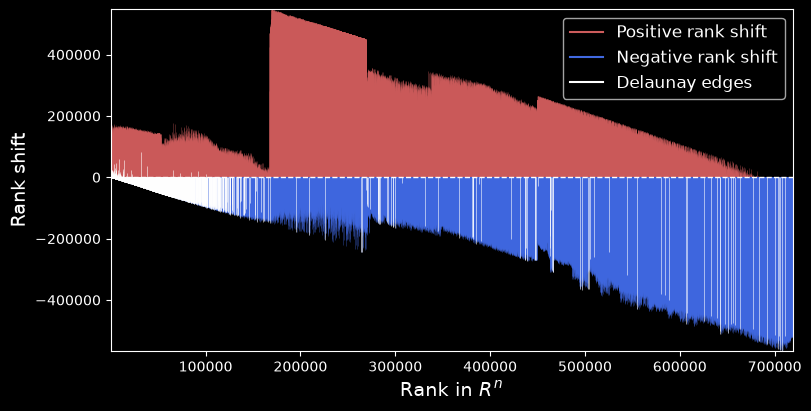

In [11]:
visualizer.plot_rank_shift_with_delaunay_fast(res, edges_delaunay_orig, filename=f"rank_shift_{dataset}_{method}_new_test", output_path= output_plot_folder)

# Sensitivity & Robustness Analysis

### Pertubation

In [12]:
perturbation_levels = cfg.PERTURBATION_LEVELS                      # Pertubation level used. 

In [13]:
results = []

for pert_level in perturbation_levels:

    print(f"\nProcessing perturbation = {pert_level}")

    # =====================================================
    # Perturb data
    # =====================================================
    data_pert = utility.perturb_dataset(
        D,
        noise_ratio=pert_level,
        random_state=42
    )

    np.save(
        f"{output_folder}/D_{dataset}_{pert_level}.npy",
        data_pert
    )

    # =====================================================
    # Projection
    # =====================================================
    proj_viz_pert = ProjectionAnalysisVisualizer(
        data=data_pert,
        class_label=class_label,
        projection_method=method,
        perplexity=perplexity,
        output_path=output_folder
    )

    low_dm_emb_pert = (
        proj_viz_pert.projection_emb_low_dim()
    )

    np.save(
        f"{output_folder}/embedding_{dataset}_{pert_level}.npy",
        low_dm_emb_pert
    )

    # =====================================================
    # Delaunay
    # =====================================================
    tri_delaunay_pert = (
        proj_viz_pert.delaunay_triangulation(
            embedding=low_dm_emb_pert
        )
    )

    edges_delaunay_pert, _ = (
        utility.extract_delaunay_edges_2d(
            tri_delaunay_pert
        )
    )

    np.save(
        f"{output_folder}/edges_{dataset}_{pert_level}.npy",
        edges_delaunay_pert
    )

    # =====================================================
    # Layout enrichment
    # =====================================================
    intensity_interp_cordinates_pert, \
    max_interp_pert, \
    min_interp_pert = (
        proj_viz_pert.delanay_hd_edge_lenghts_inter()
    )

    np.save(
        f"{output_folder}/intensity_interp_cordinates_{dataset}_{pert_level}.npy",
        intensity_interp_cordinates_pert
    )

    # =====================================================
    # Edge preservation
    # =====================================================
    metrics = utility.compare_edge_sets(
        edges_delaunay_orig,
        edges_delaunay_pert
    )

    metrics["noise_ratio"] = pert_level
    np.save(f"{output_folder}/metrics_{dataset}_{pert_level}.npy", metrics)


    results.append({
        "perturbation": pert_level,
        "preserved_ratio":
            metrics["preserved_ratio"],
        "lost_ratio":
            metrics["lost_ratio"],
        "new_ratio":
            metrics["new_ratio"],
        "jaccard_similarity":
            metrics["jaccard_similarity"]
    })

# =========================================================
# Save summary table
# =========================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    f"{output_folder}/edge_preservation_summary.csv",
    index=False
)

results_df


Processing perturbation = 0.0

Processing perturbation = 0.01

Processing perturbation = 0.1

Processing perturbation = 0.2

Processing perturbation = 0.3


,perturbation,preserved_ratio,lost_ratio,new_ratio,jaccard_similarity
0,0.00,1.000000,0.000000,0.000000,1.000000
1,0.01,0.475818,0.524182,0.522505,0.312523
2,0.10,0.103718,0.896282,0.896841,0.054679
3,0.20,0.045010,0.954990,0.955549,0.023016
4,0.30,0.030193,0.969807,0.969248,0.015332


# Plotting pertubation results 

> **Note:** Plotting functions and visualization examples are provided in the **`plots.ipynb`** notebook.